In [7]:
dir_path = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50_v3/injections/injection_2/outdir/output'
metric_path = os.path.join(dir_path, 'analysis_metric.pkl')
with open(metric_path, 'rb') as f:
    metric = pickle.load(f)

In [80]:
from simple_pe.param_est.pe import SimplePESamples
from pesummary.utils.samples_dict import SamplesDict

In [92]:
def create_metric_vectors(metric, mass_ratio_last=True, eccentricity_last=True):

    # Order list of parameter directions
    params = np.array(metric.dx_directions.copy())
    final_params = []
    if eccentricity_last:
        final_params += ['ecc10', 'ecc10sqrd']
    if mass_ratio_last:
        final_params += ['mass_ratio', 'inverted_mass_ratio', 'symmetric_mass_ratio']
    for final_param in final_params:
        if final_param in params:
            params = np.delete(params, np.where(params == final_param))
            params = np.append(params, final_param)
    base_par_evs = np.identity(len(params))
    print(params)
    
    # Orthogonalise in dx space
    default_evs = [np.array(metric.normalized_evecs()[param]) for param in params]
    dx_evs = np.matmul(np.linalg.inv(default_evs), base_par_evs)
    ev_list = dx_evs.T
    orth_ev_list = []
    for i in range(len(ev_list)):
        new_ev = ev_list[i].copy()
        for j in range(len(orth_ev_list)):
            norm = np.dot(orth_ev_list[j], orth_ev_list[j])
            new_ev -= np.dot(ev_list[i], orth_ev_list[j])*orth_ev_list[j]/norm
        orth_ev_list.append(new_ev)
    for i in range(len(orth_ev_list)):
        orth_ev_list[i] = orth_ev_list[i]/np.sqrt(np.dot(orth_ev_list[i], orth_ev_list[i]))
    print(orth_ev_list)

    # Convert back to parameter space
    par_evs = np.matmul(default_evs, np.array(orth_ev_list).T)
    par_ev_dict = SimplePESamples(SamplesDict(params, par_evs))

    return par_ev_dict

In [72]:
metric.normalized_evecs()

<function SimplePESamples.values>

In [93]:
create_metric_vectors(metric, mass_ratio_last=True, eccentricity_last=True)

['chirp_mass' 'chi_align' 'ecc10sqrd' 'symmetric_mass_ratio']
[array([ 0.95787768, -0.06808094,  0.16021243, -0.22840164]), array([0.10313841, 0.04274827, 0.5659904 , 0.81681694]), array([ 0.04917872, -0.91249445, -0.31318291,  0.25855715]), array([-0.26346588, -0.40111277,  0.74558924, -0.46237536])]


{'chirp_mass': Array([ 0.73855508,  2.6008981 , -1.44250706,  3.43364477]),
 'chi_align': Array([ 1.04083409e-17,  2.05233952e-01, -2.72808728e-02,
         8.03340217e-02]),
 'ecc10sqrd': Array([ 4.33680869e-19, -1.73472348e-18,  3.55448373e-02,
        -6.69830214e-03]),
 'symmetric_mass_ratio': Array([-8.67361738e-19,  0.00000000e+00, -1.73472348e-18,
         3.17368135e-02])}

In [6]:
import os
import pickle
import json
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from simple_pe.param_est import eccentric_peak

In [3]:
def get_ang_seps(injections_dir):
    
    ang_seps = []
    ecc10s = []
    chirps = []
    etas = []
    chi_as = []
    networks = []
    metric_mms = []
    e10_mms = []
    peak_mms = []
    for i, inj_dir in tqdm(enumerate(sorted(os.listdir(injections_dir)))):

        # Try to load in necessary files
        inj_dir = os.path.join(injections_dir, inj_dir)
        inj_dir = os.path.join(inj_dir, 'outdir/output/')
        try:
            filter_metric_path = os.path.join(inj_dir, 'filter_metric.pkl')
            with open(filter_metric_path, 'rb') as f:
                metric = pickle.load(f)
            analysis_metric_path = os.path.join(inj_dir, 'analysis_metric.pkl')
            with open(analysis_metric_path, 'rb') as f:
                analysis_metric = pickle.load(f)
            inj_path = os.path.join(inj_dir, 'converted_injection_parameters.json')
            with open(inj_path, 'r') as f:
                all_inj_params = json.load(f)
            all_inj_params['posterior_samples']['ecc10sqrd'] = [all_inj_params['posterior_samples']['ecc10'][0]**2]
            peak_path = os.path.join(inj_dir, 'peak_parameters.json')
            with open(peak_path, 'r') as f:
                all_peak_params = json.load(f)
        except:
            continue

        # Save injected parameters and metric mismatch
        ecc10s.append(all_inj_params['posterior_samples']['ecc10'][0])
        chirps.append(all_inj_params['posterior_samples']['chirp_mass'][0])
        etas.append(all_inj_params['posterior_samples']['symmetric_mass_ratio'][0])
        chi_as.append(all_inj_params['posterior_samples']['chi_align'][0])
        networks.append(all_inj_params['posterior_samples']['network'][0])
        metric_mms.append(metric.mismatch)

        # Calculate vectors in dx space
        inj_delta = [all_inj_params['posterior_samples'][dx][0] - metric.x[dx][0] for dx in metric.dx_directions]
        peak_delta = [all_peak_params['posterior_samples'][dx][0] - metric.x[dx][0] for dx in metric.dx_directions]
        inj_dx = np.matmul(np.linalg.inv(metric.normalized_evecs().samples), inj_delta)
        peak_dx = np.matmul(np.linalg.inv(metric.normalized_evecs().samples), peak_delta)

        # Calculate angle between vectors
        inj_dx_norm = inj_dx/np.linalg.norm(inj_dx)
        peak_dx_norm = peak_dx/np.linalg.norm(peak_dx)
        ang = np.arccos(np.dot(inj_dx_norm, peak_dx_norm))
        ang_seps.append(ang)

        # Calculate most ecc point of metric
        e10_mm = np.sqrt(eccentric_peak.const_mm_point(
                     metric, metric.mismatch, 'ecc10sqrd'
                 )['ecc10sqrd'])
        e10_mms.append(e10_mm)

        # Calculate mismatch between peak and injected
        inj_params = np.zeros(len(analysis_metric.dxs))
        for i, dx in enumerate(analysis_metric.dxs):
            inj_params[i] = all_inj_params['posterior_samples'][dx][0]
            inj_params[i] -= analysis_metric.x[dx][0]
        inj_params_dx = np.matmul(np.linalg.inv(analysis_metric.normalized_evecs().samples), inj_params)
        norm_dist = np.sqrt(np.sum(inj_params_dx**2))
        peak_mms.append(analysis_metric.mismatch[0]*norm_dist**2)

    # keep_inds = np.arange(len(peak_mms))
    keep_inds = np.array(peak_mms) < 0.3

    return np.array(ang_seps)[keep_inds], np.array(ecc10s)[keep_inds], np.array(chirps)[keep_inds], np.array(etas)[keep_inds], np.array(chi_as)[keep_inds], np.array(networks)[keep_inds], np.array(metric_mms)[keep_inds], np.array(e10_mms)[keep_inds], np.array(peak_mms)[keep_inds]

In [4]:
injections_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50_v3/injections'
ang_seps, ecc10s, chirps, etas, chi_as, networks, metric_mms, e10_mms, peak_mms = get_ang_seps(injections_dir)

50it [00:01, 25.68it/s]


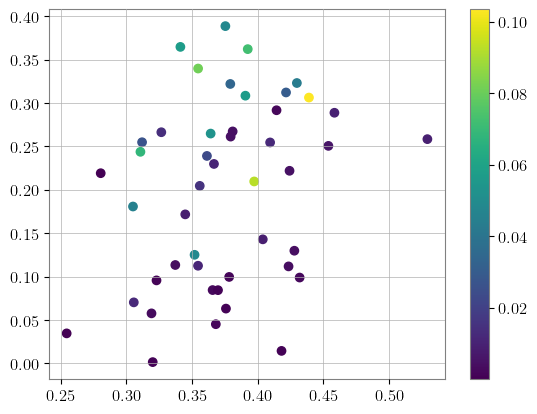

In [81]:
plt.scatter(e10_mms, ecc10s, c=peak_mms)
plt.colorbar()

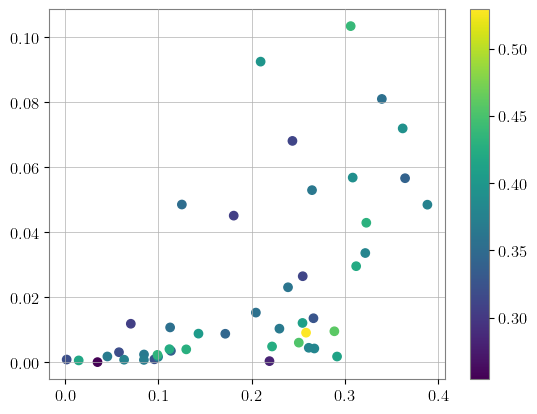

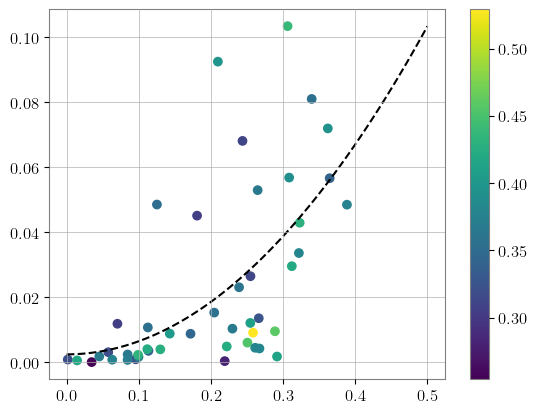

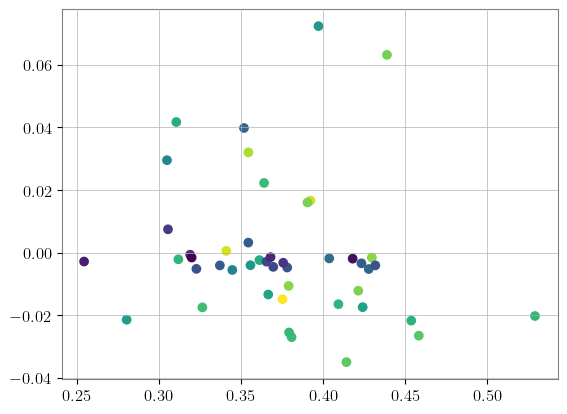

In [86]:
from scipy import optimize

def lin(x, m, c):
    return m*x + c

def quad(x, a, b, c):
    return a*x**2 +b*x + c

popt, pcov = optimize.curve_fit(quad, ecc10s, peak_mms)

plt.scatter(ecc10s, peak_mms, c=e10_mms)
es = np.linspace(0, 0.5, 101)
plt.plot(es, quad(es, *popt), c='k', ls='dashed')
plt.colorbar()
plt.show()

plt.scatter(e10_mms, peak_mms - quad(np.array(ecc10s), *popt), c=ecc10s)
plt.show()

In [7]:
popt

array([-1.79868137,  1.49389349])